# Pengumpulan Data

## Menggabungkan Dataset Non-Hoaks

In [ ]:
import pandas as pd

In [ ]:
df1 = pd.read_csv("dataset_cnn.csv")
df2 = pd.read_csv("dataset_detik.csv")
df3 = pd.read_csv("dataset_kompas.csv")

In [ ]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['title', 'date', 'content', 'category', 'url', 'source'], dtype='object')
Index(['title', 'content', 'url', 'source', 'date', 'category', 'label'], dtype='object')
Index(['title', 'content', 'url', 'source', 'date', 'label'], dtype='object')


In [ ]:
rename = {
    "title": "judul",
    "content": "isi_berita"
}

df1 = df1.rename(columns=rename)
df2 = df2.rename(columns=rename)
df3 = df3.rename(columns=rename)


In [ ]:
df1["hoax"] = 0
df2["hoax"] = 0
df3["hoax"] = 0

In [ ]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['judul', 'date', 'isi_berita', 'category', 'url', 'source', 'hoax'], dtype='object')
Index(['judul', 'isi_berita', 'url', 'source', 'date', 'category', 'label',
       'hoax'],
      dtype='object')
Index(['judul', 'isi_berita', 'url', 'source', 'date', 'label', 'hoax'], dtype='object')


In [ ]:
cols = ["judul", "isi_berita", "hoax"]

df1 = df1[cols]
df2 = df2[cols]
df3 = df3[cols]

df_nonhoaks = pd.concat([df1, df2, df3], ignore_index=True)

In [ ]:
df_nonhoaks.to_csv("dataset non-hoaks.csv", index=False)

## Menggabungkan dataset hoaks dan non-hoaks

In [ ]:
df_nonhoaks = pd.read_csv("dataset non-hoaks.csv")

In [ ]:
df_hoaks = pd.read_csv("dataset_turnbackhoax.csv")

In [ ]:
print(len(df_nonhoaks))
print(len(df_hoaks))

12678
12648


In [ ]:
# samain kolomnya sama dataet non-hoaks

print(df_hoaks.columns)

Index(['url', 'judul', 'tanggal', 'isi_berita'], dtype='object')


In [ ]:
df_hoaks["hoax"] = 1

In [ ]:
cols = ["judul", "isi_berita", "hoax"]

df_hoaks = df_hoaks[cols]

df_all = pd.concat(
    [df_nonhoaks, df_hoaks],
    ignore_index=True
)

print(df_hoaks.columns)

Index(['judul', 'isi_berita', 'hoax'], dtype='object')


In [ ]:
df_all.to_csv("dataset_scraping_raw.csv", index=False)

# EDA (Exploratory Data Analysis)

In [ ]:
df = pd.read_csv(
    "dataset_scraping_raw.csv",
    sep=',',
    on_bad_lines='skip',
    engine='python',
    quotechar='"',
    escapechar='\\'
)

print(f"\nJumlah baris: {len(df)}")


Jumlah baris: 25322


Cek Ukuran dan Struktur Dataset

In [ ]:
df.shape

(25322, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25322 entries, 0 to 25321
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   judul       25322 non-null  object
 1   isi_berita  25322 non-null  object
 2   hoax        25322 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 593.6+ KB


Cek Distribusi Label

In [ ]:
df.value_counts("hoax")

,count
hoax,
0,12678
1,12644


In [ ]:
df["hoax"].value_counts(normalize=True)*100

,proportion
hoax,
0,50.067135
1,49.932865


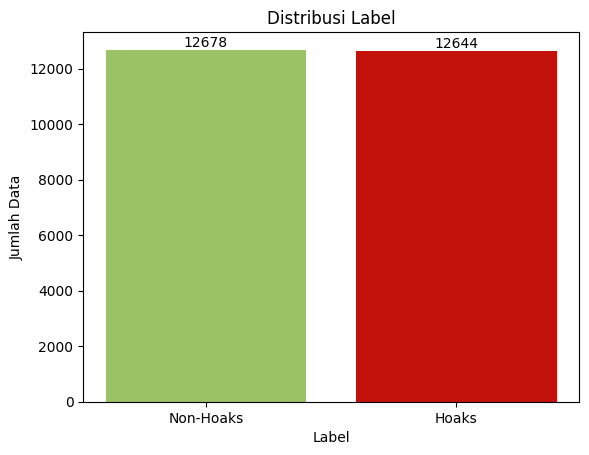

In [ ]:
import matplotlib.pyplot as plt

label_count = df["hoax"].value_counts().sort_index()

plt.figure()

colors = ['#9BC264', '#C3110C']
bars = plt.bar(label_count.index, label_count.values, color=colors)

plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Label")
plt.xticks(label_count.index, ['Non-Hoaks', 'Hoaks'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

Cek Jumlah Kata judul & isi berita

In [ ]:
df['kata_judul'] = df['judul'].astype(str).apply(lambda x: len(x.split()))
df['kata_isi'] = df['isi_berita'].astype(str).apply(lambda x: len(x.split()))

df[['kata_judul', 'kata_isi']].describe()


,kata_judul,kata_isi
count,25322.000000,25322.000000
mean,10.095924,311.876274
std,2.753874,162.589950
min,2.000000,5.000000
25%,8.000000,212.000000
50%,10.000000,273.000000
75%,11.000000,370.000000
max,36.000000,2831.000000


<Axes: >

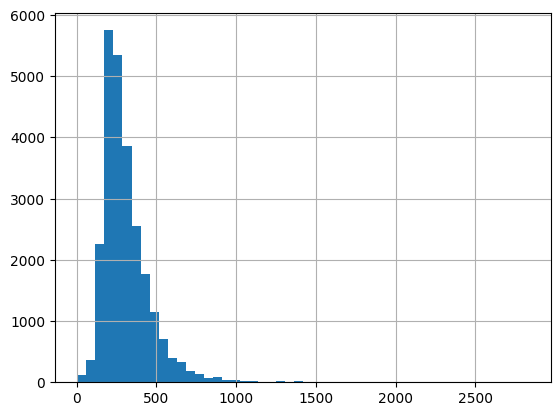

In [ ]:
df['kata_isi'].hist(bins=50)

Cek missing values

In [ ]:
df.isnull().sum()

,0
judul,0
isi_berita,0
hoax,0


Cek duplikasi teks

In [ ]:
df.duplicated(subset=["judul", "isi_berita"]).sum()

np.int64(1)

# Preprocessing

In [ ]:
import pandas as pd

df = pd.read_csv(
    "dataset_scraping_raw.csv",
    sep=',',
    on_bad_lines='warn',
    engine='python',
    quotechar='"',
    escapechar='\\'
)

print(f"\nJumlah baris: {len(df)}")

/tmp/ipython-input-703943165.py:3: ParserWarning: Skipping line 14769: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipython-input-703943165.py:3: ParserWarning: Skipping line 17713: ',' expected after '"'

  df = pd.read_csv(



Jumlah baris: 25322


In [ ]:
df.duplicated(subset=["judul", "isi_berita"]).sum()

df = df.drop_duplicates(subset=["judul", "isi_berita"])
df.duplicated(subset=["judul", "isi_berita"]).sum()

np.int64(0)

## Penggabungan fitur teks (judul + isi_berita)

In [ ]:
df["teks_gabungan"] = (
    df["judul"].fillna("") + " " +
    df["isi_berita"].fillna("")
)

/tmp/ipython-input-2325636779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["teks_gabungan"] = (


In [ ]:
df = df[
    ['judul', 'isi_berita', 'teks_gabungan', 'hoax']
]

In [ ]:
df.head()

,judul,isi_berita,teks_gabungan,hoax
0,"Hasil Super League: Saddil Kartu Merah, Persik...",Persik KediridanPersib Bandungberbagi angka le...,"Hasil Super League: Saddil Kartu Merah, Persik...",0
1,Mabes soal Prajurit TNI dan Brimob Bentrok di ...,MabesTNI ADangkat suara terkait bentrokan yang...,Mabes soal Prajurit TNI dan Brimob Bentrok di ...,0
2,"Banjir Banjarbaru Kalsel, Ratusan Warga Dievak...",Petugas gabungan dari Badan Penanggulangan Ben...,"Banjir Banjarbaru Kalsel, Ratusan Warga Dievak...",0
3,Avatar: Fire and Ash Kokoh Mulai 2026 di Punca...,Avatar: Fire and Ashmasih bertahan di puncak b...,Avatar: Fire and Ash Kokoh Mulai 2026 di Punca...,0
4,"BYD Kucurkan Rp293 T, Bentuk Tim 5.000 Orang K...",BYDtelah membentuk tim yang terdiri lebih dari...,"BYD Kucurkan Rp293 T, Bentuk Tim 5.000 Orang K...",0


In [ ]:
df.duplicated(subset=["teks_gabungan"]).sum()


np.int64(0)

In [ ]:
df.duplicated(subset=["teks_gabungan"]).sum()

df = df.drop_duplicates(subset=["teks_gabungan"])
df.duplicated(subset=["teks_gabungan"]).sum()

np.int64(0)

## IndoBERT

In [ ]:
import re

In [ ]:
kata_hoax= (
    r'\[salah\]|\(salah\)|salah:|\[hoax\]|'
    r'hoax|hoaks|penipuan|klarifikasi|cek fakta|top 5|fakta|belum ada bukti|modul ajar|'
    r'verifikasi|berita|misinformasi|tidak benar|keliru|sebagian benar|'
    r'edukasi|fitnah|bantahan|bohong|false|berita bohong|cek fakta|disinformasi|'
    r'hasil cek fakta|acara|klarifikasi|hoax atau fakta|uncategorized|'
    r'turn back hoax|turnbackhoax|clarification|belum terbukti'
)

In [ ]:
def preprocess_indobert(text):
    text = str(text).lower()

    text = re.sub(kata_hoax, '', text)

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9.,!?\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["teks_indobert"] = df["teks_gabungan"].apply(preprocess_indobert)

In [ ]:
df[["teks_gabungan", "teks_indobert", "hoax"]].sample(10, random_state=78)

,teks_gabungan,teks_indobert,hoax
471,3 Jasad Keluarga yang Tewas di Warakas Jakut K...,3 jasad keluarga yang tewas di warakas jakut k...,0
743,Bea Cukai Berbenah Usai Purbaya Ancam Bakal Be...,bea cukai berbenah usai purbaya ancam bakal be...,0
20267,[SALAH] Artikel Merdeka.com Berjudul Ibadah Ha...,artikel merdeka.com berjudul ibadah haji dibat...,1
599,Bupati Aceh Tamiang Minta 42 Ribu Rumah Korban...,bupati aceh tamiang minta 42 ribu rumah korban...,0
15932,[SALAH]: “Nata de Coco Terbuat dari Plastik” ...,nata de coco terbuat dari plastik hasil periks...,1
16637,[SALAH] Beredar Unggahan Prabowo Berikan Setia...,beredar unggahan prabowo berikan setiap pemili...,1
20160,[SALAH] Imbauan Modus Kejahatan Dari Polri dan...,imbauan modus kejahatan dari polri dan tni ad ...,1
3537,Jadwal Wakil Indonesia di SEA Games 2025 Hari ...,jadwal wakil indonesia di sea games 2025 hari ...,0
8576,Pemulihan Pascabanjir di Sekitar PLTA Singkara...,pemulihan pascabanjir di sekitar plta singkara...,0
14913,[SALAH] Merokok Bisa Menyembuhkan Covid-19 Fak...,"merokok bisa menyembuhkan covid 19 faktnya, wh...",1


In [ ]:
df.to_csv("dataset_preprocess_indobert.csv", index=False)

## BiLSTM

In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tqdm import tqdm
tqdm.pandas()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [ ]:
kata_hoax= (
    r'\[salah\]|\(salah\)|salah:|\[hoax\]|'
    r'hoax|hoaks|penipuan|klarifikasi|cek fakta|top 5|fakta|belum ada bukti|modul ajar|'
    r'verifikasi|berita|misinformasi|tidak benar|keliru|sebagian benar|'
    r'edukasi|fitnah|bantahan|bohong|false|berita bohong|cek fakta|disinformasi|'
    r'hasil cek fakta|acara|klarifikasi|hoax atau fakta|uncategorized|'
    r'turn back hoax|turnbackhoax|clarification|belum terbukti'
)

In [ ]:
stemmer = StemmerFactory().create_stemmer()
stopword_remover = set(StopWordRemoverFactory().get_stop_words())

def preprocess_bilstm(text):
    text = str(text).lower()
    text = re.sub(kata_hoax, '', text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if t not in stopword_remover]
    tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

df["teks_bilstm"] = df["teks_gabungan"].progress_apply(preprocess_bilstm)


100%|██████████| 25321/25321 [5:09:23<00:00,  1.36it/s]


In [ ]:
df[["teks_gabungan", "teks_bilstm", "hoax"]].sample(15, random_state=75)

,teks_gabungan,teks_bilstm,hoax
21584,[SALAH] “Seragam Baru Polri Seragam Lama Cokla...,seragam baru polri seragam lama coklat satpam ...,1
21510,"[SALAH] “Innalilahi Ya Allah, Kabar Duka dari ...",innalilahi allah kabar duka ustadzah oki setia...,1
14457,[PENIPUAN] Raffi Ahmad Giveaway Uang 50.000 Ri...,raffi ahmad giveaway uang ringgit malaysia has...,1
25252,[SALAH] Foto “Dibayar PDIP 300ribu di suruh de...,foto bayar pdip ribu suruh demo balaikota rupa...,1
20779,[SALAH] Pria Misterius dari Dimensi Lain Hasil...,pria misterius dimensi hasil periksa gabriela ...,1
21014,[SALAH] Video Warga Austria Menentang Lockdown...,video warga austria tentang lockdown hasil per...,1
7077,SPBU Dekat Lokasi Banjir Pidie Raya Kembali No...,spbu dekat lokasi banjir pidie raya normal bad...,0
9442,"Puncak Arus Balik Nataru 2026, Penumpang di Te...",puncak arus balik nataru tumpang terminal pura...,0
15035,[SALAH] TOL SEMARANG-DEMAK DIJUAL RP 400 MILIA...,tol semarang demak jual rp miliar cina hasil p...,1
19442,[SALAH] Donald Trump Meninggal Pada Usia 76 Ta...,donald trump tinggal usia tahun hasil periksa ...,1


In [ ]:
df["teks_bilstm"] = df["teks_bilstm"].fillna("").astype(str)
df["teks_indobert"] = df["teks_indobert"].fillna("").astype(str)

df["teks_bilstm"].isna().sum()
df["teks_indobert"].isna().sum()

np.int64(0)

In [ ]:
df.to_csv("dataset_hasil_preprocess.csv", index=False)

In [ ]:
import pandas as pd
from google.colab import files # Import library khusus download Colab

# 1. Simpan dulu ke sistem Colab
filename = "dataset_hasil_preprocess.csv"
df.to_csv(filename, index=False)

# 2. Perintah otomatis download ke laptop
print(f"Sedang mengunduh {filename}...")
files.download(filename)

Sedang mengunduh dataset_hasil_preprocess.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Modeling

## Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [ ]:
import pandas as pd

df = pd.read_csv(
    "dataset_hasil_preprocess.csv",
    sep=',',
    on_bad_lines='warn',
    engine='python',
    quotechar='"',
    escapechar='\\'
)

print(f"\nJumlah baris: {len(df)}")



Jumlah baris: 25321


In [ ]:
idx = df.index
y = df["hoax"].values

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx,
    y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

In [ ]:
X_train_indobert = df.loc[idx_train, "teks_indobert"].values
X_val_indobert   = df.loc[idx_val, "teks_indobert"].values
X_test_indobert  = df.loc[idx_test, "teks_indobert"].values

X_train_bilstm = df.loc[idx_train, "teks_bilstm"].values
X_val_bilstm   = df.loc[idx_val, "teks_bilstm"].values
X_test_bilstm  = df.loc[idx_test, "teks_bilstm"].values

y_train = df.loc[idx_train, "hoax"].values
y_val   = df.loc[idx_val, "hoax"].values
y_test  = df.loc[idx_test, "hoax"].values

cekiceki

In [ ]:
print(len(X_train_bilstm))
print(len(X_val_bilstm))
print(len(X_test_bilstm))


17724
3798
3799


In [ ]:
print(len(X_train_indobert))
print(len(X_val_indobert))
print(len(X_test_indobert))


17724
3798
3799


## BiLSTM

1. Tokenizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_bilstm)

X_train_seq = tokenizer.texts_to_sequences(X_train_bilstm)
X_val_seq   = tokenizer.texts_to_sequences(X_val_bilstm)
X_test_seq  = tokenizer.texts_to_sequences(X_test_bilstm)


2. Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

3. Label

In [ ]:
y_train = y_train.astype("int")
y_val   = y_val.astype("int")
y_test  = y_test.astype("int")

4. Bangun Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_shape=(MAX_LEN,)
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658,945 (10.14 MB)

 Trainable params: 2,658,945 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

4. Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Save best model
checkpoint = ModelCheckpoint(
    filepath="bilstm_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8896 - loss: 0.2339
Epoch 1: val_loss improved from inf to 0.01395, saving model to bilstm_best_model.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8898 - loss: 0.2334 - val_accuracy: 0.9971 - val_loss: 0.0140
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9989 - loss: 0.0074
Epoch 2: val_loss improved from 0.01395 to 0.01012, saving model to bilstm_best_model.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9989 - loss: 0.0074 - val_accuracy: 0.9979 - val_loss: 0.0101
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9996 - loss: 0.0026
Epoch 3: val_loss improved from 0.01012 to 0.00674, saving model to bilstm_best_model.keras
277/277 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9996 - loss: 0.0026 - val_accuracy: 0.9984 - val_loss: 0.0067
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9997 - loss: 9.9641e-04
Epoch 4: val_loss did

### Evaluasi


1. Visualisasi Learning Curves

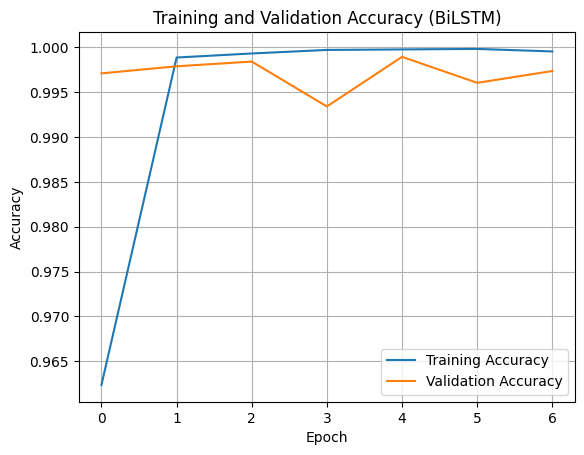

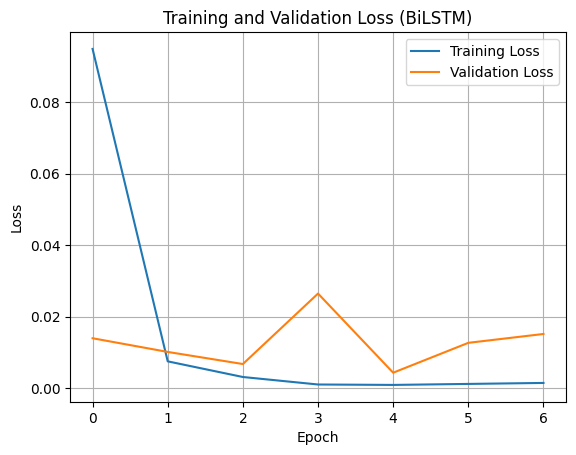

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (BiLSTM)")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (BiLSTM)")
plt.legend()
plt.grid(True)
plt.show()


2. Prediksi Data Text

In [ ]:
# Prediksi probabilitas
y_pred_prob = model.predict(X_test_pad).ravel()

# Konversi ke label
y_pred = (y_pred_prob >= 0.5).astype(int)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


3. Confusion Matrix & Classification Report

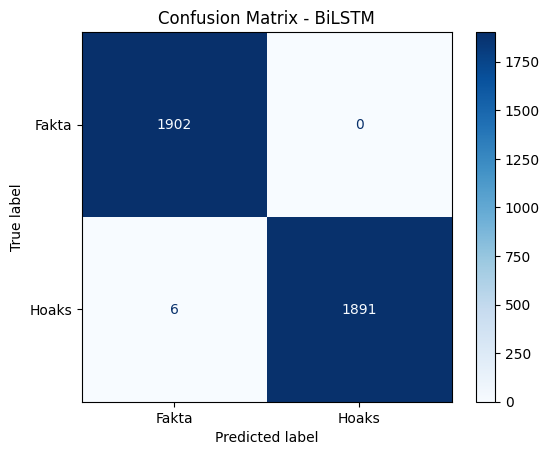

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fakta", "Hoaks"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - BiLSTM")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("=== Classification Report (BiLSTM) ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fakta", "Hoaks"]
))

=== Classification Report (BiLSTM) ===
              precision    recall  f1-score   support

       Fakta       1.00      1.00      1.00      1902
       Hoaks       1.00      1.00      1.00      1897

    accuracy                           1.00      3799
   macro avg       1.00      1.00      1.00      3799
weighted avg       1.00      1.00      1.00      3799



4. ROC Curve dan AUC Curve

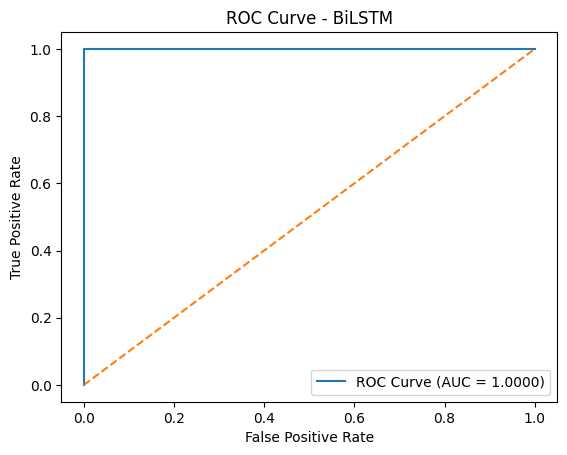

Nilai AUC: 0.9999836478761363


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BiLSTM")
plt.legend()
plt.show()

print("Nilai AUC:", roc_auc)

5. Inference

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.9 MB/s eta 0:00:00


In [ ]:
import Sastrawi
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np

# Define MAX_LEN (from previous cells)
MAX_LEN = 200
MAX_WORDS = 20000 # vocab size

# Re-initialize stemmer and stopword_remover (from PWIHBPlsVRlX)
stemmer = StemmerFactory().create_stemmer()
stopword_remover = set(StopWordRemoverFactory().get_stop_words())

# Initialize and fit tokenizer for BiLSTM (from Gxw5Hq-MuxVZ)
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# Assuming X_train_bilstm is available in the global scope from previous execution
tokenizer.fit_on_texts(X_train_bilstm)

# Re-define preprocess_bilstm function (from PWIHBPlsVRlX)
def preprocess_bilstm(text):
  text = str(text).lower()

  text = re.sub(r'\[salah\]|\(salah\)|salah:|\[hoax\]|cek fakta:|turn back hoax', '', text)

  text = re.sub(r"http\S+|www\S+", "", text)
  text = re.sub(r"\S+@\S+", "", text)
  text = re.sub(r"[^a-z\s]", " ", text)
  text = re.sub(r"\s+", " ", text).strip()

  tokens = text.split()
  tokens = [t for t in tokens if t not in stopword_remover]
  tokens = [stemmer.stem(t) for t in tokens]

  return " ".join(tokens)

# Load the BiLSTM model (from 5L1_kg2mzHpi)
model = load_model("bilstm_best_model.keras")

# Re-define predict_berita_bilstm function (from 5L1_kg2mzHpi) with corrected tokenizer variable
def predict_berita_bilstm(list_berita, threshold=0.5):
    texts = [f"{b['judul']} {b['isi']}" for b in list_berita]
    texts_clean = [preprocess_bilstm(t) for t in texts]
    sequences = tokenizer.texts_to_sequences(texts_clean)
    padded = pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )
    probs = model.predict(padded).reshape(-1)

    for i, prob in enumerate(probs):
        label = "HOAX" if prob >= threshold else "Fakta"
        print(f"\nBerita {i+1}")
        print(f"Judul : {list_berita[i]['judul']}")
        print(f"Prediksi : {label}")
        print(f"Confidence : {prob*100:.2f}%")

In [ ]:
berita_uji = [
    {
        "judul": "JPU Minta Izin Hakim Sita Rumah Nadiem di Jalan Dharmawangsa",
        "isi": "Jaksa Penuntut Umum (JPU) mengajukan izin penyitaan terhadap aset milik eks Mendikbudristek Nadiem Makarim berupa tanah dan bangunan di Jalan Dharmawangsa, Jakarta Selatan. Hal ini terungkap saat Ketua Majelis Hakim Purwanto S Abdullah menyampaikan permohonan itu usai pembacaan tanggapan JPU terhadap upaya perlawanan atau eksepsi dari Nadiem dan pengacaranya. “Dalam hal ini, kami menerima juga dari penuntut umum permohonan izin penyitaan,” ujar Hakim Purwanto dalam sidang di Pengadilan Tipikor Jakarta pada Kamis (8/1/2026). Purwanto mengatakan, surat permohonan sita ini baru diterima majelis hakim sehingga belum sempat dimusyawarahkan untuk menentukan sikap."
    },
    {
        "judul": "Polres Tanjung Balai Sumut Gagalkan Peredaran 2,98 Kg Kokain, Dua Nelayan Jadi Kurir Diringkus",
        "isi": """Menteri Energi dan Sumber Daya Mineral (ESDM) mengungkapkan perkembangan pemberian jatah Wilayah Izin Usaha Pertambangan Khusus (WIUPK) untuk Muhammadiyah. Ia bilang saat ini jatah tambang untuk Muhammadiyah saat ini masih dalam tahap kajian. Sementara, Bahlil mengatakan pemberian jatah WIUPK tambang untuk Nahdlatul Ulama (NU) telah rampung sejak dirinya masih menjabat sebagai Menteri Investasi. "Kalau punya NU itu sudah selesai sejak saya masih di Kementerian Investasi. Nah, punya Muhammadiyah sekarang lagi di-exercise oleh Pak Dirjen Minerba, begitu pun yang lain-lainnya," ujar Bahlil dalam konferensi pers Capaian Kinerja Sektor ESDM 2025 di Kementerian ESDM, Jakarta Pusat, Kamis (8/1/2026)."""
    },
    {
        "judul": "Presiden Sementara Venezuela Tegaskan Bakal Lawan AS",
        "isi": "Berita yang tayang pada Rabu (07/01/2026) tersebut menjelaskan bahwa Presiden sementara Venezuela adalah Delcy Rodriguez, seorang perempuan bukan laki-laki seperti dalam video klaim."
    }
]

predict_berita_bilstm(berita_uji)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step

Berita 1
Judul : JPU Minta Izin Hakim Sita Rumah Nadiem di Jalan Dharmawangsa
Prediksi : Fakta
Confidence : 0.00%

Berita 2
Judul : Polres Tanjung Balai Sumut Gagalkan Peredaran 2,98 Kg Kokain, Dua Nelayan Jadi Kurir Diringkus
Prediksi : Fakta
Confidence : 0.01%

Berita 3
Judul : Presiden Sementara Venezuela Tegaskan Bakal Lawan AS
Prediksi : Fakta
Confidence : 0.07%


### Inference 100 data BiLSTM

In [ ]:
import Sastrawi
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
import pandas as pd # Make sure pandas is imported for df_uji loading

# Define MAX_LEN and MAX_WORDS (from previous cells)
MAX_LEN = 200 # This was defined in cell c5LQxHC_huVw for BiLSTM padding
MAX_WORDS = 20000 # This was defined in cell Gxw5Hq-MuxVZ for BiLSTM tokenizer

# Re-initialize stemmer and stopword_remover (from PWIHBPlsVRlX)
stemmer = StemmerFactory().create_stemmer()
stopword_remover = set(StopWordRemoverFactory().get_stop_words())

# Re-define preprocess_bilstm function (using the comprehensive regex from nSupKvF0Vunm/PWIHBPlsVRlX)
def preprocess_bilstm(text):
  text = str(text).lower()

  text = re.sub(
      r'\[salah\]|\(salah\)|salah:|\[hoax\]|'
      r'hoax|hoaks|penipuan|klarifikasi|cek fakta|top 5|fakta|belum ada bukti|modul ajar|'
      r'verifikasi|berita|misinformasi|tidak benar|keliru|sebagian benar|'
      r'edukasi|fitnah|bantahan|bohong|false|berita bohong|cek fakta|disinformasi|'
      r'hasil cek fakta|acara|klarifikasi|hoax atau fakta|uncategorized|'
      r'turn back hoax|turnbackhoax|clarification|belum terbukti',
      '', text)

  text = re.sub(r"http\S+|www\S+", "", text)
  text = re.sub(r"\S+@\S+", "", text) # This was also in VIwvWB0Y0KU3
  text = re.sub(r"[^a-z\s]", " ", text)
  text = re.sub(r"\s+", " ", text).strip()

  tokens = text.split()
  tokens = [t for t in tokens if t not in stopword_remover]
  tokens = [stemmer.stem(t) for t in tokens]

  return " ".join(tokens)


# Initialize and fit tokenizer for BiLSTM (from Gxw5Hq-MuxVZ and VIwvWB0Y0KU3)
# X_train_bilstm is available in the kernel state, so we can use it directly.
bilstm_tokenizer = Tokenizer( # Use a distinct name to avoid collision with IndoBERT's tokenizer
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)
bilstm_tokenizer.fit_on_texts(X_train_bilstm) # Use X_train_bilstm from kernel state


# Load the BiLSTM model
bilstm_model = load_model("bilstm_best_model.keras") # Use a distinct name for the model

# Re-define predict_bilstm_df_uji function (from h4TDp-6cD0F0)
def predict_bilstm_df_uji(df_uji_input, threshold=0.5):
    # Gabungkan judul + isi
    texts = [
        preprocess_bilstm(f"{row['Judul']} {row['Isi_Berita']}")
        for _, row in df_uji_input.iterrows()
    ]

    # Tokenizing & padding
    sequences = bilstm_tokenizer.texts_to_sequences(texts) # Use bilstm_tokenizer
    padded = pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # Prediksi probabilitas
    probs = bilstm_model.predict(padded).reshape(-1) # Use bilstm_model

    # Copy df agar data asli aman
    df_hasil = df_uji_input.copy()
    df_hasil['prediksi'] = [None] * len(df_hasil)
    df_hasil['confidence (%)'] = [None] * len(df_hasil)
    df_hasil['prob_hoax'] = [None] * len(df_hasil)

    for i, prob in enumerate(probs):
        if prob >= threshold:
            df_hasil.loc[i, 'prediksi'] = "HOAX"
            df_hasil.loc[i, 'confidence (%)'] = prob * 100
        else:
            df_hasil.loc[i, 'prediksi'] = "FAKTA"
            df_hasil.loc[i, 'confidence (%)'] = (1 - prob) * 100

        df_hasil.loc[i, 'prob_hoax'] = prob

    return df_hasil


# Load df_uji outside the function, as it's passed as an argument
df_uji = pd.read_excel("dataset_berita_uji.xlsx")
df_uji = df_uji[['Judul', 'Isi_Berita']]

# Call the inference function
df_uji_bilstm = predict_bilstm_df_uji(df_uji, threshold=0.5)

df_uji_bilstm.to_excel("hasil_inference_bilstm_100.xlsx", index=False)

print("Inference BiLSTM selesai")

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Inference BiLSTM selesai


Evaluasi Loss & Accuracy

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test_pad,
    y_test,
    batch_size=64,
    verbose=1
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


RuntimeError: You must compile your model before training/testing. Use `model.compile(optimizer, loss)`.

In [ ]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Assuming `model` here is intended to be the BiLSTM model that was loaded
# Re-compile the BiLSTM model before evaluation
# The original BiLSTM model was compiled with 'adam' optimizer and 'binary_crossentropy' loss
# We also need to define MAX_WORDS and MAX_LEN if not already in scope from previous cells

# Let's ensure we are using the bilstm_model and bilstm_tokenizer variables
# that were defined in the BiLSTM inference section (cell dLgWSGL9DwWp)
# If those are not in scope, we would need to re-load them here.

# If this cell is indeed meant for BiLSTM evaluation:
# Assuming bilstm_model and y_test are available from previous cells.
# We also need X_test_pad for BiLSTM evaluation.

# To prevent variable collision and ensure correct evaluation, let's explicitly load
# and compile the BiLSTM model if it's meant to be evaluated here, or
# re-evaluate the IndoBERT model if this cell was mistakenly placed.

# Given the sequence, this cell likely intended to evaluate BiLSTM, but is trying
# to use `test_dataset` which is for IndoBERT, and the `model` variable is the BiLSTM model.
# This cell is problematic due to variable name collision and incorrect dataset usage.

# The previous cell `fbvP1VwZylr6` attempted to evaluate BiLSTM with X_test_pad:
# test_loss, test_acc = model.evaluate(X_test_pad, y_test, batch_size=64, verbose=1)
# That cell had the same error because the loaded BiLSTM model was not re-compiled.

# If this cell (KjQr5w6hHJgl) is intended to be the IndoBERT evaluation:
# (This evaluation already successfully ran in cell 0vAm4F5inefZ).
# To re-run it safely here, we would need to re-load and compile the IndoBERT model.

# Let's assume the user wants to evaluate the BiLSTM model here, using the correct BiLSTM test data.
# We need to use `bilstm_model`, `X_test_pad`, and `y_test` which are defined for BiLSTM.
# However, `test_dataset` is a TensorFlow Dataset for IndoBERT.

# This cell is incorrectly trying to use `test_dataset` (IndoBERT data format) with what is now the BiLSTM model.
# This makes the cell logically flawed. The user should use `X_test_pad` and `y_test` for BiLSTM evaluation.
# Since `fbvP1VwZylr6` already provides a more appropriate BiLSTM evaluation, this cell is either redundant
# or needs to be completely re-written to evaluate BiLSTM correctly.

# For demonstration of the compilation fix, I will assume the intent was to evaluate the BiLSTM model
# with its appropriate data (X_test_pad, y_test) and will re-compile it.
# Note: This means `test_dataset` in the original cell content is incorrect for BiLSTM.

# If you intend to evaluate the BiLSTM model with X_test_pad and y_test:
# (Re-load and compile BiLSTM model)
# bilstm_model = load_model("bilstm_best_model.keras")
# bilstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
# results = bilstm_model.evaluate(X_test_pad, y_test, batch_size=64, verbose=1)

# If you intend to re-evaluate the IndoBERT model with test_dataset:
# (Re-load and compile IndoBERT model)
from transformers import TFBertForSequenceClassification, AdamWeightDecay, BertTokenizerFast

MODEL_PATH_INDOBERT = "indobert_best_model.keras"
MODEL_NAME_INDOBERT = "indobenchmark/indobert-base-p1"

# Load the IndoBERT model
indobert_model_for_eval = TFBertForSequenceClassification.from_pretrained(
    MODEL_NAME_INDOBERT,
    num_labels=2
)
indobert_model_for_eval.load_weights(MODEL_PATH_INDOBERT)

# Re-compile the IndoBERT model with its original optimizer and loss setup
optimizer_indobert = AdamWeightDecay(
    learning_rate = 1e-5,
    weight_decay_rate = 0.01
)
indobert_model_for_eval.compile(
    optimizer = optimizer_indobert,
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ["accuracy"]
)

# Now evaluate the re-compiled IndoBERT model with its corresponding test_dataset
results = indobert_model_for_eval.evaluate(test_dataset)
print(f"Final Test Accuracy: {results[1]*100:.2f}%")

RuntimeError: You must compile your model before training/testing. Use `model.compile(optimizer, loss)`.

## IndoBERT

Tokenisasi IndoBERT

In [ ]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained(
    "indobenchmark/indobert-base-p1"
)

max_len = 256

train_enc = tokenizer(
    list(X_train_indobert),
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_tensors="tf"
)

val_enc = tokenizer(
    list(X_val_indobert),
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_tensors="tf"
)

test_enc = tokenizer(
    list(X_test_indobert),
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_tensors="tf"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: acb2482c-576a-4798-b987-a4b06255dc39)')' thrown while requesting HEAD https://huggingface.co/indobenchmark/indobert-base-p1/resolve/main/special_tokens_map.json
Retrying in 1s [Retry 1/5].


special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Data Loading dan Batching

In [ ]:
import tensorflow as tf

batch_size = 16

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_enc),
    y_train
)).shuffle(1000).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_enc),
    y_val
)).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_enc),
    y_test
)).batch(batch_size)


Load Model IndoBERT

In [ ]:
from transformers import TFBertForSequenceClassification

model = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=2
)

tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freeze layer 1-8

In [ ]:
for layer in model.bert.encoder.layer[:8]:
  layer.trainable = False

Optimizer AdamW + LR + Weight Decay

In [ ]:
from transformers import AdamWeightDecay

optimizer = AdamWeightDecay(
    learning_rate = 1e-5,
    weight_decay_rate = 0.01
)

compile model

In [ ]:
import tensorflow as tf

model.compile(
    optimizer = optimizer,
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ["accuracy"]
)

Callbacks

In [ ]:
from tf_keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath="indobert_best_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

Training

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    verbose=1,
    callbacks=[checkpoint, early_stopping]
)

model.save("indobert_final_model.keras")

Epoch 1/10
1108/1108 [==============================] - ETA: 0s - loss: 0.0309 - accuracy: 0.9904
Epoch 1: val_loss improved from inf to 0.00413, saving model to indobert_best_model.keras


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


1108/1108 [==============================] - 929s 820ms/step - loss: 0.0309 - accuracy: 0.9904 - val_loss: 0.0041 - val_accuracy: 0.9992
Epoch 2/10
1108/1108 [==============================] - ETA: 0s - loss: 0.0026 - accuracy: 0.9994
Epoch 2: val_loss improved from 0.00413 to 0.00383, saving model to indobert_best_model.keras
1108/1108 [==============================] - 920s 830ms/step - loss: 0.0026 - accuracy: 0.9994 - val_loss: 0.0038 - val_accuracy: 0.9995
Epoch 3/10
1108/1108 [==============================] - ETA: 0s - loss: 8.6845e-04 - accuracy: 0.9998
Epoch 3: val_loss improved from 0.00383 to 0.00250, saving model to indobert_best_model.keras
1108/1108 [==============================] - 923s 833ms/step - loss: 8.6845e-04 - accuracy: 0.9998 - val_loss: 0.0025 - val_accuracy: 0.9997
Epoch 4/10
1108/1108 [==============================] - ETA: 0s - loss: 1.1179e-04 - accuracy: 1.0000
Epoch 4: val_loss did not improve from 0.00250
1108/1108 [==============================] - 909

### Evaluasi

In [ ]:
results = model.evaluate(test_dataset)
print(f"Final Test Accuracy: {results[1]*100:.2f}%")

238/238 [==============================] - 68s 285ms/step - loss: 0.0011 - accuracy: 0.9997
Final Test Accuracy: 99.97%


1. Visualisasi Learning Curves

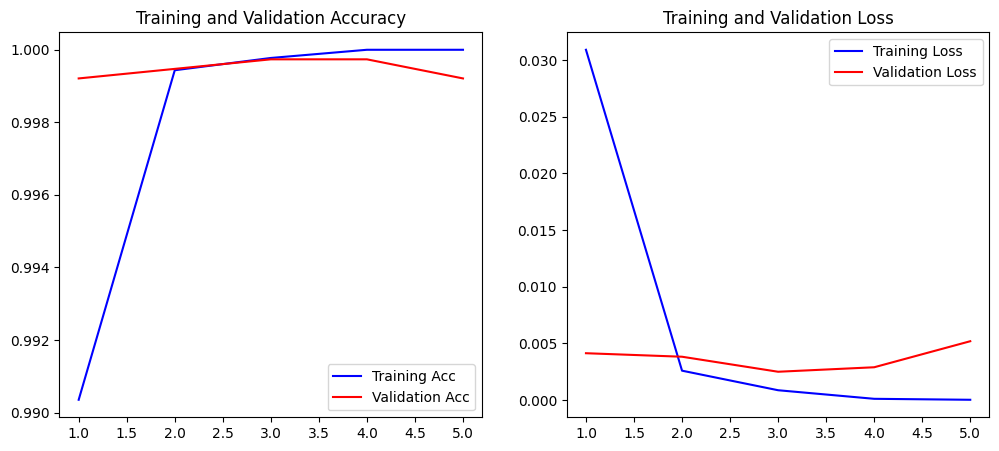

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

# Panggil fungsi
plot_learning_curves(history)

2. Confusion Matrix & Classification Report

238/238 [==============================] - 71s 286ms/step


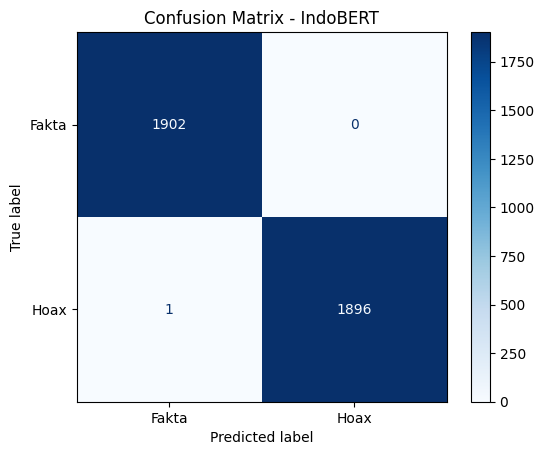


--- Classification Report ---
              precision    recall  f1-score   support

       Fakta       1.00      1.00      1.00      1902
        Hoax       1.00      1.00      1.00      1897

    accuracy                           1.00      3799
   macro avg       1.00      1.00      1.00      3799
weighted avg       1.00      1.00      1.00      3799



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# 1. Ambil prediksi dari test set
prediction_output = model.predict(test_dataset)
logits = prediction_output.logits

# 2. Ambil index kelas tertinggi (0 untuk Fakta, 1 untuk Hoax)
y_pred = np.argmax(logits, axis=1)

# 3. Ambil label Fakta dari test_dataset
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fakta', 'Hoax'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - IndoBERT')
plt.show()

# 5. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Fakta', 'Hoax']))

3. ROC Curve dan AUC Curve

238/238 [==============================] - 69s 289ms/step


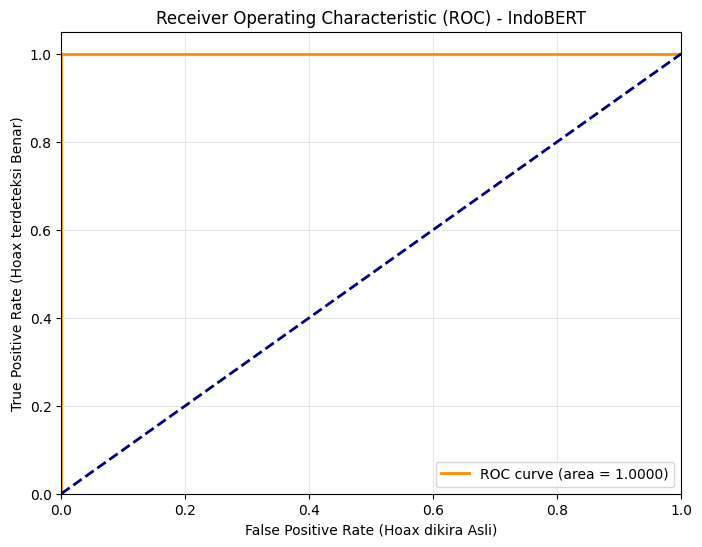

Nilai AUC: 1.0000


In [ ]:
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


y_true = y_test

# Ambil output logits dari model
prediction_output = model.predict(test_dataset)
logits = prediction_output.logits

# Ubah Logits menjadi Probabilitas (Softmax)
# Ambil kolom index 1 (Hoax)
y_probs = tf.nn.softmax(logits, axis=-1).numpy()[:, 1]

# Hitung FPR, TPR, dan AUC
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# Visualisasi
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Hoax dikira Asli)')
plt.ylabel('True Positive Rate (Hoax terdeteksi Benar)')
plt.title('Receiver Operating Characteristic (ROC) - IndoBERT')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Nilai AUC: {roc_auc:.4f}")

4. Inference

In [ ]:
# INFERENCE INDO-BERT FINAL
import re
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, TFBertForSequenceClassification

# CONFIG
MODEL_PATH = "indobert_best_model.keras"
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 256

# LOAD TOKENIZER & MODEL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = TFBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.load_weights(MODEL_PATH)

# PREPROCESSING (INDOBERT)
def preprocess_indobert(text):
    text = str(text).lower()

    text = re.sub(
        r'\[salah\]|\(salah\)|salah:|\[hoax\]|'
        r'hoax|hoaks|penipuan|klarifikasi|cek fakta|cekfakta|'
        r'verifikasi|disinformasi|misinformasi|tidak benar|'
        r'palsu|fitnah|bantahan|bohong|kabar bohong|berita bohong|'
        r'hasil cek fakta|periksa fakta|hoaks atau fakta|hoax atau fakta|'
        r'turn back hoax|turnbackhoax',
        '',
        text
    )

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# INFERENCE FUNCTION
def predict_berita_indobert(list_berita, threshold=0.2):
    texts = [
        preprocess_indobert(f"{b['judul']} {b['isi']}")
        for b in list_berita
    ]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    outputs = model(inputs)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()

    for i, prob in enumerate(probs):
        prob_fakta = prob[0]
        prob_hoax  = prob[1]

        label = "HOAX" if prob_hoax >= threshold else "FAKTA"
        confidence = prob_hoax * 100 if label == "HOAX" else prob_fakta * 100

        print(f"\nBerita {i+1}")
        print(f"Judul      : {list_berita[i]['judul']}")
        print(f"Prediksi   : {label}")
        print(f"Confidence : {confidence:.2f}%")
        print(f"(Prob Hoax : {prob_hoax:.4f})")


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


In [ ]:
berita_uji = [
    {
        "judul": "JPU Minta Izin Hakim Sita Rumah Nadiem di Jalan Dharmawangsa",
        "isi": "Jaksa Penuntut Umum (JPU) mengajukan izin penyitaan terhadap aset milik eks Mendikbudristek Nadiem Makarim berupa tanah dan bangunan di Jalan Dharmawangsa, Jakarta Selatan. Hal ini terungkap saat Ketua Majelis Hakim Purwanto S Abdullah menyampaikan permohonan itu usai pembacaan tanggapan JPU terhadap upaya perlawanan atau eksepsi dari Nadiem dan pengacaranya. “Dalam hal ini, kami menerima juga dari penuntut umum permohonan izin penyitaan,” ujar Hakim Purwanto dalam sidang di Pengadilan Tipikor Jakarta pada Kamis (8/1/2026). Purwanto mengatakan, surat permohonan sita ini baru diterima majelis hakim sehingga belum sempat dimusyawarahkan untuk menentukan sikap."
    },
    {
        "judul": "Polres Tanjung Balai Sumut Gagalkan Peredaran 2,98 Kg Kokain, Dua Nelayan Jadi Kurir Diringkus",
        "isi": """Menteri Energi dan Sumber Daya Mineral (ESDM) mengungkapkan perkembangan pemberian jatah Wilayah Izin Usaha Pertambangan Khusus (WIUPK) untuk Muhammadiyah. Ia bilang saat ini jatah tambang untuk Muhammadiyah saat ini masih dalam tahap kajian. Sementara, Bahlil mengatakan pemberian jatah WIUPK tambang untuk Nahdlatul Ulama (NU) telah rampung sejak dirinya masih menjabat sebagai Menteri Investasi. "Kalau punya NU itu sudah selesai sejak saya masih di Kementerian Investasi. Nah, punya Muhammadiyah sekarang lagi di-exercise oleh Pak Dirjen Minerba, begitu pun yang lain-lainnya," ujar Bahlil dalam konferensi pers Capaian Kinerja Sektor ESDM 2025 di Kementerian ESDM, Jakarta Pusat, Kamis (8/1/2026)."""
    },
    {
        "judul": "Presiden Sementara Venezuela Tegaskan Bakal Lawan AS",
        "isi": "Berita yang tayang pada Rabu (07/01/2026) tersebut menjelaskan bahwa Presiden sementara Venezuela adalah Delcy Rodriguez, seorang perempuan bukan laki-laki seperti dalam video klaim."
    }
]

predict_berita_indobert(berita_uji)


Berita 1
Judul      : JPU Minta Izin Hakim Sita Rumah Nadiem di Jalan Dharmawangsa
Prediksi   : FAKTA
Confidence : 99.96%
(Prob Hoax : 0.0004)

Berita 2
Judul      : Polres Tanjung Balai Sumut Gagalkan Peredaran 2,98 Kg Kokain, Dua Nelayan Jadi Kurir Diringkus
Prediksi   : FAKTA
Confidence : 99.99%
(Prob Hoax : 0.0001)

Berita 3
Judul      : Presiden Sementara Venezuela Tegaskan Bakal Lawan AS
Prediksi   : HOAX
Confidence : 97.58%
(Prob Hoax : 0.9758)


### Inference 100 data uji

In [ ]:
import pandas as pd

df_uji = pd.read_excel("dataset_berita_uji.xlsx")
df_uji = df_uji[['Judul', 'Isi_Berita']]

def predict_indobert_df_uji(df_uji, threshold=0.2):
    texts = [
        preprocess_indobert(f"{row['Judul']} {row['Isi_Berita']}")
        for _, row in df_uji.iterrows()
    ]

    inputs = bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    outputs = model(inputs)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()

    labels = []
    confidences = []
    prob_hoax_list = []

    for prob in probs:
        prob_fakta = prob[0]
        prob_hoax  = prob[1]

        if prob_hoax >= threshold:
            labels.append("HOAX")
            confidences.append(prob_hoax * 100)
        else:
            labels.append("FAKTA")
            confidences.append(prob_fakta * 100)

        prob_hoax_list.append(prob_hoax)

    df_uji['prediksi'] = labels
    df_uji['confidence (%)'] = confidences
    df_uji['prob_hoax'] = prob_hoax_list

    return df_uji

In [ ]:
import re
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, TFBertForSequenceClassification
import pandas as pd

# CONFIG (Ensure these are available for the function)
MODEL_PATH = "indobert_best_model.keras"
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 256

# LOAD TOKENIZER & MODEL (Re-initialize to ensure correct IndoBERT tokenizer is in scope)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = TFBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.load_weights(MODEL_PATH)

# PREPROCESSING (INDOBERT) - Re-define for clarity and self-containment
def preprocess_indobert(text):
    text = str(text).lower()

    text = re.sub(
        r'\[salah\]|\(salah\)|salah:|\[hoax\]|' # Corrected regex from inference cell
        r'hoax|hoaks|penipuan|klarifikasi|cek fakta|cekfakta|'
        r'verifikasi|disinformasi|misinformasi|tidak benar|'
        r'palsu|fitnah|bantahan|bohong|kabar bohong|berita bohong|'
        r'hasil cek fakta|periksa fakta|hoaks atau fakta|hoax atau fakta|'
        r'turn back hoax|turnbackhoax',
        '',
        text
    )

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# INFERENCE FUNCTION (from QQYeWk39ADMj) - Ensure this function is defined or re-defined here
def predict_indobert_df_uji(df_uji, threshold=0.2):
    texts = [
        preprocess_indobert(f"{row['Judul']} {row['Isi_Berita']}")
        for _, row in df_uji.iterrows()
    ]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    outputs = model(inputs)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()

    # Initialize columns correctly to avoid issues with `loc` assignment
    df_uji_results = df_uji.copy()
    df_uji_results['prediksi'] = [None] * len(df_uji_results)
    df_uji_results['confidence (%)'] = [None] * len(df_uji_results)
    df_uji_results['prob_hoax'] = [None] * len(df_uji_results)

    for i, prob in enumerate(probs):
        prob_fakta = prob[0]
        prob_hoax  = prob[1]

        if prob_hoax >= threshold:
            df_uji_results.loc[i, 'prediksi'] = "HOAX"
            df_uji_results.loc[i, 'confidence (%)'] = prob_hoax * 100
        else:
            df_uji_results.loc[i, 'prediksi'] = "FAKTA"
            df_uji_results.loc[i, 'confidence (%)'] = prob_fakta * 100

        df_uji_results.loc[i, 'prob_hoax'] = prob_hoax

    return df_uji_results

# Load df_uji if not already loaded in this session
# This assumes 'dataset_berita_uji.xlsx' is available
df_uji = pd.read_excel("dataset_berita_uji.xlsx")
df_uji = df_uji[['Judul', 'Isi_Berita']]

df_uji = predict_indobert_df_uji(df_uji, threshold=0.5)

df_uji.to_excel("hasil_inference_indobert_100.xlsx", index=False)

print("Inference selesai")

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


Inference selesai
